In [2]:
# ============================================================
# CELL 1 — Mount Google Drive & Setup Paths
# ============================================================

import os
from google.colab import drive

# --- Mount Drive (only if not already mounted) ---
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print("✅ Drive already mounted, skipping.")

# --- Define project root (separate from Flickr8k project) ---
PROJECT_ROOT = '/content/drive/MyDrive/DL_Project_CLEVR'
DATASET_DIR  = os.path.join(PROJECT_ROOT, 'clevr')
MODELS_DIR   = os.path.join(PROJECT_ROOT, 'models')
RESULTS_DIR  = os.path.join(PROJECT_ROOT, 'results')

# --- Create folders if they don't exist ---
for folder in [PROJECT_ROOT, DATASET_DIR, MODELS_DIR, RESULTS_DIR]:
    os.makedirs(folder, exist_ok=True)

print(f"📁 PROJECT_ROOT : {PROJECT_ROOT}")
print(f"📁 DATASET_DIR  : {DATASET_DIR}")
print(f"📁 MODELS_DIR   : {MODELS_DIR}")
print(f"📁 RESULTS_DIR  : {RESULTS_DIR}")
print("\n✅ Cell 1 done.")

Mounted at /content/drive
📁 PROJECT_ROOT : /content/drive/MyDrive/DL_Project_CLEVR
📁 DATASET_DIR  : /content/drive/MyDrive/DL_Project_CLEVR/clevr
📁 MODELS_DIR   : /content/drive/MyDrive/DL_Project_CLEVR/models
📁 RESULTS_DIR  : /content/drive/MyDrive/DL_Project_CLEVR/results

✅ Cell 1 done.


In [3]:
# ============================================================
# CELL 2 — Install Dependencies
# ============================================================

import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

required = {
    'datasets'     : 'datasets',
    'transformers' : 'transformers',
    'nltk'         : 'nltk',
    'Pillow'       : 'PIL',
}

for pkg_name, import_name in required.items():
    try:
        __import__(import_name)
        print(f"✅ {pkg_name} already installed, skipping.")
    except ImportError:
        print(f"⬇️  Installing {pkg_name}...")
        install(pkg_name)
        print(f"✅ {pkg_name} installed.")

# --- NLTK data for BLEU score ---
import nltk, os

nltk_data_path = os.path.join(PROJECT_ROOT, 'nltk_data')
os.makedirs(nltk_data_path, exist_ok=True)
nltk.data.path.append(nltk_data_path)

if not os.path.exists(os.path.join(nltk_data_path, 'tokenizers/punkt')):
    nltk.download('punkt', download_dir=nltk_data_path, quiet=True)
    print("✅ NLTK punkt downloaded.")
else:
    print("✅ NLTK punkt already exists, skipping.")

print("\n✅ Cell 2 done.")

✅ datasets already installed, skipping.
✅ transformers already installed, skipping.
✅ nltk already installed, skipping.
✅ Pillow already installed, skipping.
✅ NLTK punkt already exists, skipping.

✅ Cell 2 done.


In [10]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [11]:
# ============================================================
# CELL 3 — Download & Load CLEVR Dataset
# ============================================================

import os, json, zipfile, urllib.request, shutil

IMAGES_DIR    = os.path.join(DATASET_DIR, 'images')
SCENES_DIR    = os.path.join(DATASET_DIR, 'scenes')
CAPTIONS_FILE = os.path.join(DATASET_DIR, 'captions.json')

# --------------------------------------------------------
# Step 1: Check if dataset exists (without listing 70k files)
# --------------------------------------------------------
sample_image = os.path.join(IMAGES_DIR, 'train', 'CLEVR_train_000000.png')
images_ready = os.path.exists(sample_image)

if images_ready:
    print("✅ CLEVR images already in Drive, skipping download.")
else:
    print("⬇️  Downloading CLEVR v1.0 (18 GB)...")

    ZIP_PATH = os.path.join(DATASET_DIR, 'CLEVR_v1.0.zip')

    def progress(block_num, block_size, total_size):
        pct = min(block_num * block_size / total_size * 100, 100)
        if block_num % 5000 == 0:
            print(f"  ... {pct:.1f}%")

    urllib.request.urlretrieve(
        'https://dl.fbaipublicfiles.com/clevr/CLEVR_v1.0.zip',
        ZIP_PATH, reporthook=progress
    )
    print("✅ Download done. Extracting...")

    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        members = [m for m in z.namelist()
                   if 'images/train' in m or
                      'images/val'   in m or
                      'scenes'       in m]
        for i, m in enumerate(members):
            z.extract(m, DATASET_DIR)
            if i % 10000 == 0:
                print(f"  ... {i}/{len(members)}")

    extracted = os.path.join(DATASET_DIR, 'CLEVR_v1.0')
    if os.path.exists(extracted):
        for split in ['train', 'val']:
            src = os.path.join(extracted, 'images', split)
            dst = os.path.join(IMAGES_DIR, split)
            if os.path.exists(src):
                shutil.copytree(src, dst, dirs_exist_ok=True)
        scenes_src = os.path.join(extracted, 'scenes')
        if os.path.exists(scenes_src):
            shutil.copytree(scenes_src, SCENES_DIR, dirs_exist_ok=True)
        shutil.rmtree(extracted)

    os.remove(ZIP_PATH)
    print("✅ Extraction done.")

# --------------------------------------------------------
# Step 2: Generate captions if not exists
# --------------------------------------------------------
if os.path.exists(CAPTIONS_FILE):
    with open(CAPTIONS_FILE) as f:
        all_captions = json.load(f)
    print(f"✅ Captions loaded ({len(all_captions)} entries).")
else:
    print("Generating synthetic captions...")

    SIZE_MAP     = {'small': 'small', 'large': 'large'}
    COLOR_MAP    = {'gray': 'gray', 'red': 'red', 'blue': 'blue',
                    'green': 'green', 'brown': 'brown', 'purple': 'purple',
                    'cyan': 'cyan', 'yellow': 'yellow'}
    SHAPE_MAP    = {'cube': 'cube', 'sphere': 'sphere', 'cylinder': 'cylinder'}
    MATERIAL_MAP = {'rubber': 'rubber', 'metal': 'shiny'}

    def describe_object(obj):
        return (f"a {SIZE_MAP.get(obj['size'], obj['size'])} "
                f"{COLOR_MAP.get(obj['color'], obj['color'])} "
                f"{MATERIAL_MAP.get(obj['material'], obj['material'])} "
                f"{SHAPE_MAP.get(obj['shape'], obj['shape'])}")

    def get_spatial_relation(obj1, obj2):
        dx = obj2['3d_coords'][0] - obj1['3d_coords'][0]
        dy = obj2['3d_coords'][1] - obj1['3d_coords'][1]
        if abs(dx) > abs(dy):
            return "to the right of" if dx > 0 else "to the left of"
        else:
            return "in front of" if dy > 0 else "behind"

    def scene_to_captions(scene):
        objects  = scene['objects']
        captions = []
        if len(objects) == 0:
            return ["an empty scene"]
        if len(objects) == 1:
            captions.append(f"there is {describe_object(objects[0])}")
        elif len(objects) == 2:
            captions.append(
                f"{describe_object(objects[0])} and {describe_object(objects[1])}")
        else:
            parts = [describe_object(o) for o in objects[:-1]]
            captions.append(", ".join(parts) +
                            f", and {describe_object(objects[-1])}")
        if len(objects) >= 2:
            rel = get_spatial_relation(objects[0], objects[1])
            captions.append(
                f"{describe_object(objects[0])} {rel} {describe_object(objects[1])}")
        shape_counts = {}
        for o in objects:
            shape_counts[o['shape']] = shape_counts.get(o['shape'], 0) + 1
        dominant = max(shape_counts, key=shape_counts.get)
        captions.append(
            f"a scene with {len(objects)} objects including {SHAPE_MAP[dominant]}s")
        return captions

    all_captions = {}
    for split in ['train', 'val']:
        scene_file = os.path.join(SCENES_DIR, f'CLEVR_{split}_scenes.json')
        with open(scene_file) as f:
            data = json.load(f)
        print(f"Processing {split}: {len(data['scenes'])} scenes...")
        for scene in data['scenes']:
            img_name = scene['image_filename']
            all_captions[img_name] = {
                'split'    : split,
                'captions' : scene_to_captions(scene)
            }
        print(f"  ✅ {split} done.")

    with open(CAPTIONS_FILE, 'w') as f:
        json.dump(all_captions, f)
    print(f"✅ Captions saved ({len(all_captions)} scenes).")

# --------------------------------------------------------
# Summary
# --------------------------------------------------------
train_count = sum(1 for v in all_captions.values() if v['split'] == 'train')
val_count   = sum(1 for v in all_captions.values() if v['split'] == 'val')
print(f"\n📊 Train : {train_count}")
print(f"📊 Val   : {val_count}")
print(f"\n✅ Cell 3 done.")

✅ CLEVR images already in Drive, skipping download.
✅ Captions loaded (85000 entries).

📊 Train : 70000
📊 Val   : 15000

✅ Cell 3 done.


✅ Captions loaded
📊 Train : 70000
📊 Val   : 15000
📊 Captions per image : 3

--- Verifying 3 random images ---


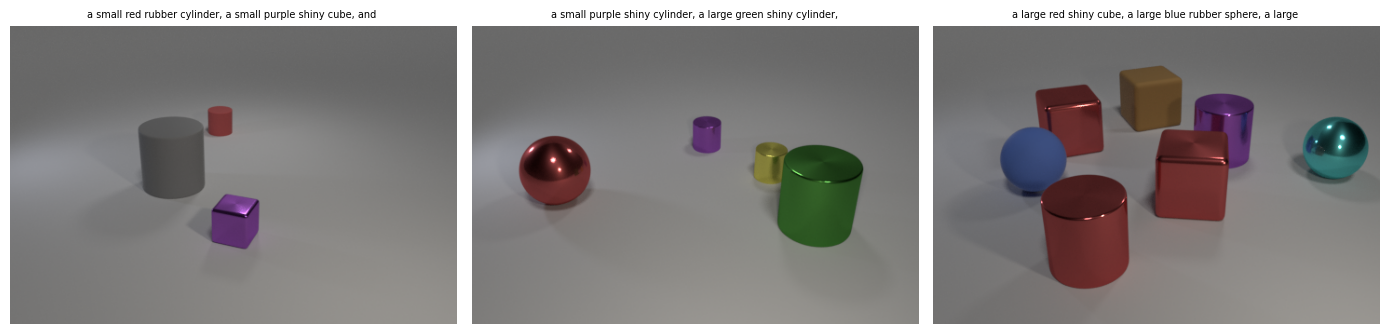


✅ Cell 4 done.


In [12]:
# ============================================================
# CELL 4 — Load & Verify Dataset
# ============================================================

import json, os, random
from PIL import Image
import matplotlib.pyplot as plt

# --------------------------------------------------------
# Load captions
# --------------------------------------------------------
with open(CAPTIONS_FILE) as f:
    all_captions = json.load(f)

train_items = [(k, v) for k, v in all_captions.items() if v['split'] == 'train']
val_items   = [(k, v) for k, v in all_captions.items() if v['split'] == 'val']

print(f"✅ Captions loaded")
print(f"📊 Train : {len(train_items)}")
print(f"📊 Val   : {len(val_items)}")
print(f"📊 Captions per image : {len(train_items[0][1]['captions'])}")

# --------------------------------------------------------
# Verify images are readable
# --------------------------------------------------------
print(f"\n--- Verifying 3 random images ---")
samples = random.sample(train_items, 3)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (img_name, data) in zip(axes, samples):
    split    = data['split']
    img_path = os.path.join(IMAGES_DIR, split, img_name)
    img      = Image.open(img_path).convert('RGB')
    caption  = data['captions'][0]

    ax.imshow(img)
    ax.set_title(caption[:60], fontsize=7, wrap=True)
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'sample_clevr.png'), dpi=100)
plt.show()
print("\n✅ Cell 4 done.")

In [13]:
# ============================================================
# CELL 5 — Build Vocabulary
# ============================================================

import os
import pickle
from collections import Counter

VOCAB_FILE = os.path.join(DATASET_DIR, 'vocab.pkl')

# --------------------------------------------------------
# Load vocabulary from cache if exists
# --------------------------------------------------------
if os.path.exists(VOCAB_FILE):
    with open(VOCAB_FILE, 'rb') as f:
        vocab = pickle.load(f)
    print(f"✅ Vocabulary loaded from cache ({len(vocab)} tokens).")
else:
    print("Building vocabulary...")

    MIN_FREQ = 2

    counter = Counter()
    for img_name, data in all_captions.items():
        for caption in data['captions']:
            counter.update(caption.lower().split())

    special_tokens = ['<PAD>', '<SOS>', '<EOS>', '<UNK>']
    words = [w for w, c in counter.items() if c >= MIN_FREQ]

    vocab = {token: idx for idx, token in enumerate(special_tokens + sorted(words))}

    with open(VOCAB_FILE, 'wb') as f:
        pickle.dump(vocab, f)

    print(f"✅ Vocabulary built and saved ({len(vocab)} tokens).")

idx2word = {idx: word for word, idx in vocab.items()}

PAD_IDX = vocab['<PAD>']
SOS_IDX = vocab['<SOS>']
EOS_IDX = vocab['<EOS>']
UNK_IDX = vocab['<UNK>']

print(f"   PAD={PAD_IDX}, SOS={SOS_IDX}, EOS={EOS_IDX}, UNK={UNK_IDX}")
print(f"\n✅ Cell 5 done.")

✅ Vocabulary loaded from cache (47 tokens).
   PAD=0, SOS=1, EOS=2, UNK=3

✅ Cell 5 done.


In [14]:
# ============================================================
# CELL 6 — Dataset Class & DataLoaders
# ============================================================

import os
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import torchvision.transforms as transforms
from PIL import Image
import random

# --------------------------------------------------------
# Image transforms
# --------------------------------------------------------
IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --------------------------------------------------------
# Dataset class
# --------------------------------------------------------
class CLEVRDataset(Dataset):
    def __init__(self, items, images_dir, vocab, transform=None):
        """
        items      : list of (img_name, {'split': ..., 'captions': [...]})
        images_dir : root images directory
        vocab      : word-to-index dictionary
        transform  : torchvision transforms
        """
        self.items      = items
        self.images_dir = images_dir
        self.vocab      = vocab
        self.transform  = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_name, data = self.items[idx]
        split          = data['split']
        img_path       = os.path.join(self.images_dir, split, img_name)

        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)

        # Randomly pick one of the 3 captions per image
        caption_str = random.choice(data['captions']).lower()
        tokens      = caption_str.split()
        caption     = ([SOS_IDX]
                       + [self.vocab.get(w, UNK_IDX) for w in tokens]
                       + [EOS_IDX])
        caption     = torch.tensor(caption, dtype=torch.long)

        return img, caption

# --------------------------------------------------------
# Collate function
# --------------------------------------------------------
def collate_fn(batch):
    imgs, captions = zip(*batch)
    imgs     = torch.stack(imgs, dim=0)
    captions = pad_sequence(captions, batch_first=True,
                            padding_value=PAD_IDX)
    return imgs, captions

# --------------------------------------------------------
# DataLoaders
# --------------------------------------------------------
BATCH_SIZE = 64

train_dataset = CLEVRDataset(train_items, IMAGES_DIR, vocab, train_transform)
val_dataset   = CLEVRDataset(val_items,   IMAGES_DIR, vocab, val_transform)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                           shuffle=True,  collate_fn=collate_fn, num_workers=0)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                           shuffle=False, collate_fn=collate_fn, num_workers=0)

print(f"Train samples : {len(train_dataset)}")
print(f"Val   samples : {len(val_dataset)}")
print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"\n✅ Cell 6 done.")

Train samples : 70000
Val   samples : 15000
Train batches : 1094
Val   batches : 235

✅ Cell 6 done.


In [15]:
# ============================================================
# CELL 7 — Model Architecture
# ============================================================

import torch
import torch.nn as nn
import torchvision.models as models
import math

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

VOCAB_SIZE = len(vocab)
EMBED_DIM  = 256
NUM_HEADS  = 8
FF_DIM     = 512
NUM_LAYERS = 2
DROPOUT    = 0.3
MAX_LEN    = 50

# --------------------------------------------------------
# FFT Decomposition
# --------------------------------------------------------
def fft_decompose(images, cutoff=20):
    B, C, H, W = images.shape
    fft        = torch.fft.fft2(images)
    fft_sh     = torch.fft.fftshift(fft)

    cy, cx     = H // 2, W // 2
    ys         = torch.arange(H, device=images.device).float() - cy
    xs         = torch.arange(W, device=images.device).float() - cx
    grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')
    mask_low   = ((grid_y**2 + grid_x**2).sqrt() <= cutoff).float()
    mask_low   = mask_low.unsqueeze(0).unsqueeze(0)
    mask_high  = 1.0 - mask_low

    low  = torch.fft.ifft2(torch.fft.ifftshift(fft_sh * mask_low)).real
    high = torch.fft.ifft2(torch.fft.ifftshift(fft_sh * mask_high)).real

    return low, high

# --------------------------------------------------------
# Spatial CNN Encoder
# --------------------------------------------------------
class SpatialCNNEncoder(nn.Module):
    def __init__(self, embed_dim, pretrained=True):
        super().__init__()
        resnet        = models.resnet18(weights='DEFAULT' if pretrained else None)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])
        self.project  = nn.Linear(512, embed_dim)
        self.norm     = nn.LayerNorm(embed_dim)

    def forward(self, x):
        feats            = self.backbone(x)           # (B, 512, 7, 7)
        B, C, H, W       = feats.shape
        feats            = feats.permute(0, 2, 3, 1)  # (B, 7, 7, 512)
        feats            = feats.reshape(B, H*W, C)   # (B, 49, 512)
        feats            = self.project(feats)         # (B, 49, embed_dim)
        return self.norm(feats)

# --------------------------------------------------------
# Positional Encoding
# --------------------------------------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, dropout, max_len=200):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe           = torch.zeros(max_len, embed_dim)
        pos          = torch.arange(max_len).unsqueeze(1).float()
        div          = torch.exp(torch.arange(0, embed_dim, 2).float()
                                 * (-math.log(10000.0) / embed_dim))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

# --------------------------------------------------------
# Baseline Model
# --------------------------------------------------------
class BaselineCaptioner(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder   = SpatialCNNEncoder(EMBED_DIM, pretrained=True)
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=PAD_IDX)
        self.pos_enc   = PositionalEncoding(EMBED_DIM, DROPOUT)
        decoder_layer  = nn.TransformerDecoderLayer(EMBED_DIM, NUM_HEADS,
                                                    FF_DIM, DROPOUT,
                                                    batch_first=True)
        self.decoder   = nn.TransformerDecoder(decoder_layer, NUM_LAYERS)
        self.fc_out    = nn.Linear(EMBED_DIM, VOCAB_SIZE)

    def forward(self, images, captions):
        memory   = self.encoder(images)
        tgt      = self.pos_enc(self.embedding(captions))
        tgt_len  = captions.size(1)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(
                       tgt_len, device=captions.device)
        pad_mask = (captions == PAD_IDX)
        out      = self.decoder(tgt, memory,
                                tgt_mask=tgt_mask,
                                tgt_key_padding_mask=pad_mask)
        return self.fc_out(out)

# --------------------------------------------------------
# FreqAware Model
# --------------------------------------------------------
class FreqAwareCaptioner(nn.Module):
    def __init__(self, cutoff=20):
        super().__init__()
        self.cutoff    = cutoff
        self.enc_low   = SpatialCNNEncoder(EMBED_DIM, pretrained=True)
        self.enc_high  = SpatialCNNEncoder(EMBED_DIM, pretrained=False)
        self.fusion    = nn.Sequential(
            nn.Linear(EMBED_DIM * 2, EMBED_DIM),
            nn.ReLU(),
            nn.LayerNorm(EMBED_DIM)
        )
        self.embedding = nn.Embedding(VOCAB_SIZE, EMBED_DIM, padding_idx=PAD_IDX)
        self.pos_enc   = PositionalEncoding(EMBED_DIM, DROPOUT)
        decoder_layer  = nn.TransformerDecoderLayer(EMBED_DIM, NUM_HEADS,
                                                    FF_DIM, DROPOUT,
                                                    batch_first=True)
        self.decoder   = nn.TransformerDecoder(decoder_layer, NUM_LAYERS)
        self.fc_out    = nn.Linear(EMBED_DIM, VOCAB_SIZE)

    def forward(self, images, captions):
        low, high  = fft_decompose(images, cutoff=self.cutoff)
        feat_low   = self.enc_low(low)
        feat_high  = self.enc_high(high)
        memory     = self.fusion(torch.cat([feat_low, feat_high], dim=-1))
        tgt        = self.pos_enc(self.embedding(captions))
        tgt_len    = captions.size(1)
        tgt_mask   = nn.Transformer.generate_square_subsequent_mask(
                         tgt_len, device=captions.device)
        pad_mask   = (captions == PAD_IDX)
        out        = self.decoder(tgt, memory,
                                  tgt_mask=tgt_mask,
                                  tgt_key_padding_mask=pad_mask)
        return self.fc_out(out)

# --------------------------------------------------------
# Sanity check
# --------------------------------------------------------
baseline_model  = BaselineCaptioner().to(DEVICE)
freqaware_model = FreqAwareCaptioner(cutoff=20).to(DEVICE)

dummy_imgs = torch.randn(2, 3, 224, 224).to(DEVICE)
dummy_caps = torch.randint(0, VOCAB_SIZE, (2, 10)).to(DEVICE)

out_b = baseline_model(dummy_imgs, dummy_caps)
out_f = freqaware_model(dummy_imgs, dummy_caps)

print(f"Baseline  output shape : {out_b.shape}")
print(f"FreqAware output shape : {out_f.shape}")

n_params_b = sum(p.numel() for p in baseline_model.parameters()  if p.requires_grad)
n_params_f = sum(p.numel() for p in freqaware_model.parameters() if p.requires_grad)
print(f"\nBaseline  params : {n_params_b:,}")
print(f"FreqAware params : {n_params_f:,}")
print(f"\n✅ Cell 7 done.")

Device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 238MB/s]
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


Baseline  output shape : torch.Size([2, 10, 47])
FreqAware output shape : torch.Size([2, 10, 47])

Baseline  params : 12,914,031
FreqAware params : 24,354,223

✅ Cell 7 done.


In [16]:
# ============================================================
# CELL 7.5 — Download CLEVR directly to local storage
# ============================================================

import os, zipfile, urllib.request, shutil

LOCAL_DIR        = '/content/clevr'
LOCAL_IMAGES_DIR = '/content/clevr/images'
local_train      = os.path.join(LOCAL_IMAGES_DIR, 'train')
local_val        = os.path.join(LOCAL_IMAGES_DIR, 'val')

if (os.path.exists(local_train) and
    len(os.listdir(local_train)) > 1000):
    print(f"✅ Already in local storage ({len(os.listdir(local_train))} train images)")
else:
    ZIP_LOCAL = '/content/CLEVR_v1.0.zip'

    print("⬇️  Downloading CLEVR to local storage (~30 min)...")

    def progress(block_num, block_size, total_size):
        pct = min(block_num * block_size / total_size * 100, 100)
        if block_num % 5000 == 0:
            print(f"  ... {pct:.1f}%")

    urllib.request.urlretrieve(
        'https://dl.fbaipublicfiles.com/clevr/CLEVR_v1.0.zip',
        ZIP_LOCAL, reporthook=progress
    )
    print("✅ Download done. Extracting...")

    os.makedirs(LOCAL_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_LOCAL, 'r') as z:
        members = [m for m in z.namelist()
                   if 'images/train' in m or 'images/val' in m]
        for i, m in enumerate(members):
            z.extract(m, LOCAL_DIR)
            if i % 10000 == 0:
                print(f"  ... {i}/{len(members)}")

    # Move to clean path
    src = os.path.join(LOCAL_DIR, 'CLEVR_v1.0', 'images')
    shutil.copytree(src, LOCAL_IMAGES_DIR, dirs_exist_ok=True)
    shutil.rmtree(os.path.join(LOCAL_DIR, 'CLEVR_v1.0'))
    os.remove(ZIP_LOCAL)
    print("✅ Extraction done.")

# Update IMAGES_DIR and rebuild DataLoaders
IMAGES_DIR = LOCAL_IMAGES_DIR

train_dataset = CLEVRDataset(train_items, IMAGES_DIR, vocab, train_transform)
val_dataset   = CLEVRDataset(val_items,   IMAGES_DIR, vocab, val_transform)

from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=64,
                          shuffle=True,  collate_fn=collate_fn, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=64,
                          shuffle=False, collate_fn=collate_fn, num_workers=2)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"\n✅ Cell 7.5 done.")

⬇️  Downloading CLEVR to local storage (~30 min)...
  ... 0.0%
  ... 0.2%
  ... 0.4%
  ... 0.6%
  ... 0.9%
  ... 1.1%
  ... 1.3%
  ... 1.5%
  ... 1.7%
  ... 1.9%
  ... 2.2%
  ... 2.4%
  ... 2.6%
  ... 2.8%
  ... 3.0%
  ... 3.2%
  ... 3.4%
  ... 3.7%
  ... 3.9%
  ... 4.1%
  ... 4.3%
  ... 4.5%
  ... 4.7%
  ... 5.0%
  ... 5.2%
  ... 5.4%
  ... 5.6%
  ... 5.8%
  ... 6.0%
  ... 6.2%
  ... 6.5%
  ... 6.7%
  ... 6.9%
  ... 7.1%
  ... 7.3%
  ... 7.5%
  ... 7.8%
  ... 8.0%
  ... 8.2%
  ... 8.4%
  ... 8.6%
  ... 8.8%
  ... 9.0%
  ... 9.3%
  ... 9.5%
  ... 9.7%
  ... 9.9%
  ... 10.1%
  ... 10.3%
  ... 10.6%
  ... 10.8%
  ... 11.0%
  ... 11.2%
  ... 11.4%
  ... 11.6%
  ... 11.8%
  ... 12.1%
  ... 12.3%
  ... 12.5%
  ... 12.7%
  ... 12.9%
  ... 13.1%
  ... 13.4%
  ... 13.6%
  ... 13.8%
  ... 14.0%
  ... 14.2%
  ... 14.4%
  ... 14.6%
  ... 14.9%
  ... 15.1%
  ... 15.3%
  ... 15.5%
  ... 15.7%
  ... 15.9%
  ... 16.2%
  ... 16.4%
  ... 16.6%
  ... 16.8%
  ... 17.0%
  ... 17.2%
  ... 17.4%
  ... 17.7%

In [17]:
# ============================================================
# CELL 8 — Train or Load Models
# ============================================================

import torch
import torch.nn as nn
import time
import json
import os

# --------------------------------------------------------
# Training config
# --------------------------------------------------------
NUM_EPOCHS    = 10
LEARNING_RATE = 3e-4
CLIP_GRAD     = 1.0

# --------------------------------------------------------
# Train one epoch
# --------------------------------------------------------
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for imgs, captions in loader:
        imgs     = imgs.to(device)
        captions = captions.to(device)
        inp      = captions[:, :-1]
        tgt      = captions[:, 1:]
        optimizer.zero_grad()
        output   = model(imgs, inp)
        output   = output.reshape(-1, output.size(-1))
        tgt      = tgt.reshape(-1)
        loss     = criterion(output, tgt)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# --------------------------------------------------------
# Validate one epoch
# --------------------------------------------------------
def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for imgs, captions in loader:
            imgs     = imgs.to(device)
            captions = captions.to(device)
            inp      = captions[:, :-1]
            tgt      = captions[:, 1:]
            output   = model(imgs, inp)
            output   = output.reshape(-1, output.size(-1))
            tgt      = tgt.reshape(-1)
            loss     = criterion(output, tgt)
            total_loss += loss.item()
    return total_loss / len(loader)

# --------------------------------------------------------
# Full training function with checkpointing
# --------------------------------------------------------
def train_model(model, model_name, num_epochs=NUM_EPOCHS):
    checkpoint_path = os.path.join(MODELS_DIR, f'{model_name}_best.pth')
    history_path    = os.path.join(RESULTS_DIR, f'{model_name}_history.json')

    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

    start_epoch = 0
    best_val    = float('inf')
    history     = {'train_loss': [], 'val_loss': []}

    if os.path.exists(checkpoint_path) and os.path.exists(history_path):
        with open(history_path) as f:
            saved_history = json.load(f)
        if len(saved_history['train_loss']) >= num_epochs:
            ckpt = torch.load(checkpoint_path, map_location=DEVICE)
            model.load_state_dict(ckpt['model_state'])
            model.eval()
            print(f"✅ {model_name} already trained — loaded best checkpoint "
                  f"(epoch {ckpt['epoch']+1}, val: {ckpt['best_val']:.4f})")
            return model, saved_history
        ckpt        = torch.load(checkpoint_path, map_location=DEVICE)
        model.load_state_dict(ckpt['model_state'])
        optimizer.load_state_dict(ckpt['optimizer_state'])
        start_epoch = len(saved_history['train_loss'])
        best_val    = ckpt['best_val']
        history     = saved_history
        print(f"Resuming {model_name} from epoch {start_epoch+1} "
              f"(best val: {best_val:.4f})")

    print(f"\n{'='*50}")
    print(f"Training: {model_name}")
    print(f"{'='*50}")

    for epoch in range(start_epoch, num_epochs):
        t0         = time.time()
        train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
        val_loss   = val_epoch(model,   val_loader,   criterion,            DEVICE)
        scheduler.step()
        elapsed    = time.time() - t0

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        print(f"Epoch [{epoch+1:02d}/{num_epochs}] "
              f"train_loss: {train_loss:.4f}  "
              f"val_loss: {val_loss:.4f}  "
              f"time: {elapsed:.1f}s")

        if val_loss < best_val:
            best_val = val_loss
            torch.save({
                'epoch'          : epoch,
                'model_state'    : model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'best_val'       : best_val,
            }, checkpoint_path)
            print(f"  → Saved best checkpoint (val: {best_val:.4f})")

        with open(history_path, 'w') as f:
            json.dump(history, f)

    print(f"\n✅ {model_name} training done. Best val loss: {best_val:.4f}")
    return model, history

# --------------------------------------------------------
# Train both models
# --------------------------------------------------------
baseline_model,  history_baseline  = train_model(baseline_model,  'baseline')
freqaware_model, history_freqaware = train_model(freqaware_model, 'freqaware')

print("\n✅ Cell 8 done.")

✅ baseline already trained — loaded best checkpoint (epoch 9, val: 0.2926)
✅ freqaware already trained — loaded best checkpoint (epoch 10, val: 0.3028)

✅ Cell 8 done.


In [18]:
# ============================================================
# CELL 9 — Beam Search Caption Generation
# ============================================================

import torch

def generate_caption(model, image, max_len=MAX_LEN, beam_size=5):
    """
    Beam search caption generation.
    Args:
        model     : captioning model
        image     : (C, H, W) tensor
        max_len   : maximum caption length
        beam_size : number of beams
    Returns:
        list of words
    """
    model.eval()
    with torch.no_grad():
        image = image.unsqueeze(0).to(DEVICE)

        beams     = [([SOS_IDX], 0.0)]
        completed = []

        for _ in range(max_len):
            new_beams = []

            for tokens, log_prob in beams:
                if tokens[-1] == EOS_IDX:
                    completed.append((tokens, log_prob))
                    continue

                tgt       = torch.tensor([tokens], dtype=torch.long).to(DEVICE)
                output    = model(image, tgt)
                logits    = output[0, -1]
                log_probs = torch.log_softmax(logits, dim=-1)

                topk_log_probs, topk_tokens = log_probs.topk(beam_size)

                for i in range(beam_size):
                    new_token    = topk_tokens[i].item()
                    new_log_prob = log_prob + topk_log_probs[i].item()
                    new_beams.append((tokens + [new_token], new_log_prob))

            if not new_beams:
                break

            new_beams.sort(key=lambda x: x[1] / len(x[0]), reverse=True)
            beams = new_beams[:beam_size]

            if all(t[-1] == EOS_IDX for t, _ in beams):
                completed.extend(beams)
                break

        if completed:
            best_tokens = max(completed,
                              key=lambda x: x[1] / len(x[0]))[0]
        else:
            best_tokens = max(beams,
                              key=lambda x: x[1] / len(x[0]))[0]

    words = [idx2word.get(t, '<UNK>') for t in best_tokens[1:]
             if t not in [EOS_IDX, PAD_IDX, SOS_IDX]]
    return words

print("✅ Beam search (beam_size=5) ready.")
print("✅ Cell 9 done.")

✅ Beam search (beam_size=5) ready.
✅ Cell 9 done.


In [19]:
# ============================================================
# CELL 10 — Evaluation & BLEU Score
# ============================================================

import torch
import json
import os
from PIL import Image
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import torchvision.transforms as transforms

# --------------------------------------------------------
# Compute BLEU on validation set
# --------------------------------------------------------
def compute_bleu(model, val_items, images_dir, transform, n_samples=500):
    refs_dict = {}
    for img_name, data in val_items:
        refs_dict[img_name] = [cap.lower().split()
                               for cap in data['captions']]

    samples   = val_items[:n_samples]
    hypotheses = []
    references = []

    for img_name, data in samples:
        split    = data['split']
        img_path = os.path.join(images_dir, split, img_name)
        img      = transform(Image.open(img_path).convert('RGB'))
        hyp      = generate_caption(model, img)
        hypotheses.append(hyp)
        references.append(refs_dict[img_name])

    smoother = SmoothingFunction().method1
    bleu1 = corpus_bleu(references, hypotheses,
                        weights=(1,0,0,0),
                        smoothing_function=smoother)
    bleu2 = corpus_bleu(references, hypotheses,
                        weights=(0.5,0.5,0,0),
                        smoothing_function=smoother)
    bleu3 = corpus_bleu(references, hypotheses,
                        weights=(0.33,0.33,0.33,0),
                        smoothing_function=smoother)
    bleu4 = corpus_bleu(references, hypotheses,
                        weights=(0.25,0.25,0.25,0.25),
                        smoothing_function=smoother)
    return bleu1, bleu2, bleu3, bleu4

# --------------------------------------------------------
# Evaluate both models
# --------------------------------------------------------
print("Evaluating Baseline  (500 samples)...")
b1, b2, b3, b4 = compute_bleu(baseline_model,  val_items,
                               IMAGES_DIR, val_transform)
print(f"  BLEU-1: {b1:.4f}  BLEU-2: {b2:.4f}  "
      f"BLEU-3: {b3:.4f}  BLEU-4: {b4:.4f}")

print("\nEvaluating FreqAware (500 samples)...")
f1, f2, f3, f4 = compute_bleu(freqaware_model, val_items,
                               IMAGES_DIR, val_transform)
print(f"  BLEU-1: {f1:.4f}  BLEU-2: {f2:.4f}  "
      f"BLEU-3: {f3:.4f}  BLEU-4: {f4:.4f}")

# --------------------------------------------------------
# Save results
# --------------------------------------------------------
results = {
    'baseline':  {'bleu1': b1, 'bleu2': b2, 'bleu3': b3, 'bleu4': b4},
    'freqaware': {'bleu1': f1, 'bleu2': f2, 'bleu3': f3, 'bleu4': f4},
}
with open(os.path.join(RESULTS_DIR, 'bleu_scores_clevr.json'), 'w') as f:
    json.dump(results, f, indent=2)

print("\n--- Summary ---")
print(f"{'Model':<12} {'BLEU-1':>8} {'BLEU-2':>8} "
      f"{'BLEU-3':>8} {'BLEU-4':>8}")
print(f"{'Baseline':<12} {b1:>8.4f} {b2:>8.4f} "
      f"{b3:>8.4f} {b4:>8.4f}")
print(f"{'FreqAware':<12} {f1:>8.4f} {f2:>8.4f} "
      f"{f3:>8.4f} {f4:>8.4f}")

print(f"\n✅ Cell 10 done.")

Evaluating Baseline  (500 samples)...
  BLEU-1: 0.9822  BLEU-2: 0.9767  BLEU-3: 0.9691  BLEU-4: 0.9574

Evaluating FreqAware (500 samples)...
  BLEU-1: 0.9754  BLEU-2: 0.9686  BLEU-3: 0.9590  BLEU-4: 0.9446

--- Summary ---
Model          BLEU-1   BLEU-2   BLEU-3   BLEU-4
Baseline       0.9822   0.9767   0.9691   0.9574
FreqAware      0.9754   0.9686   0.9590   0.9446

✅ Cell 10 done.


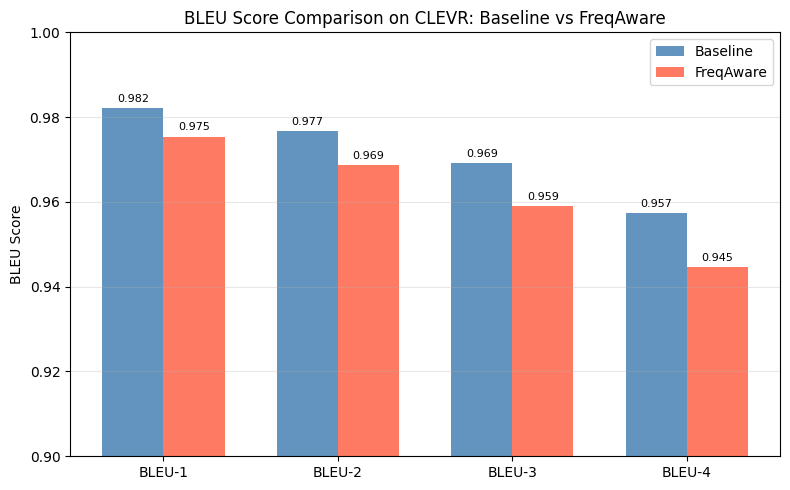

✅ Saved bleu_clevr.png


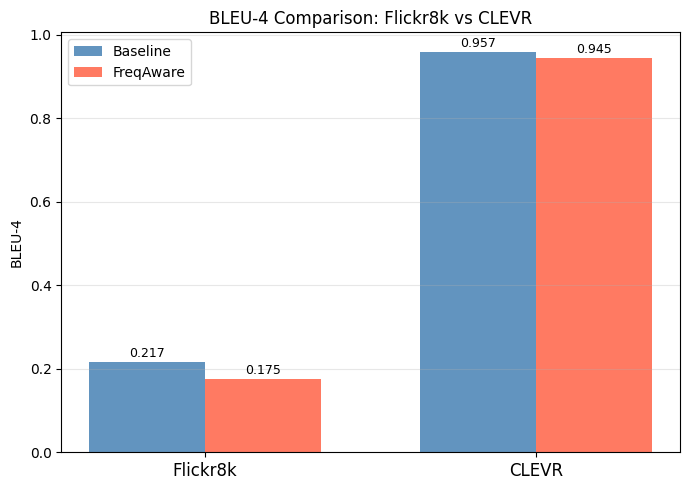

✅ Saved cross_dataset_bleu4.png


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


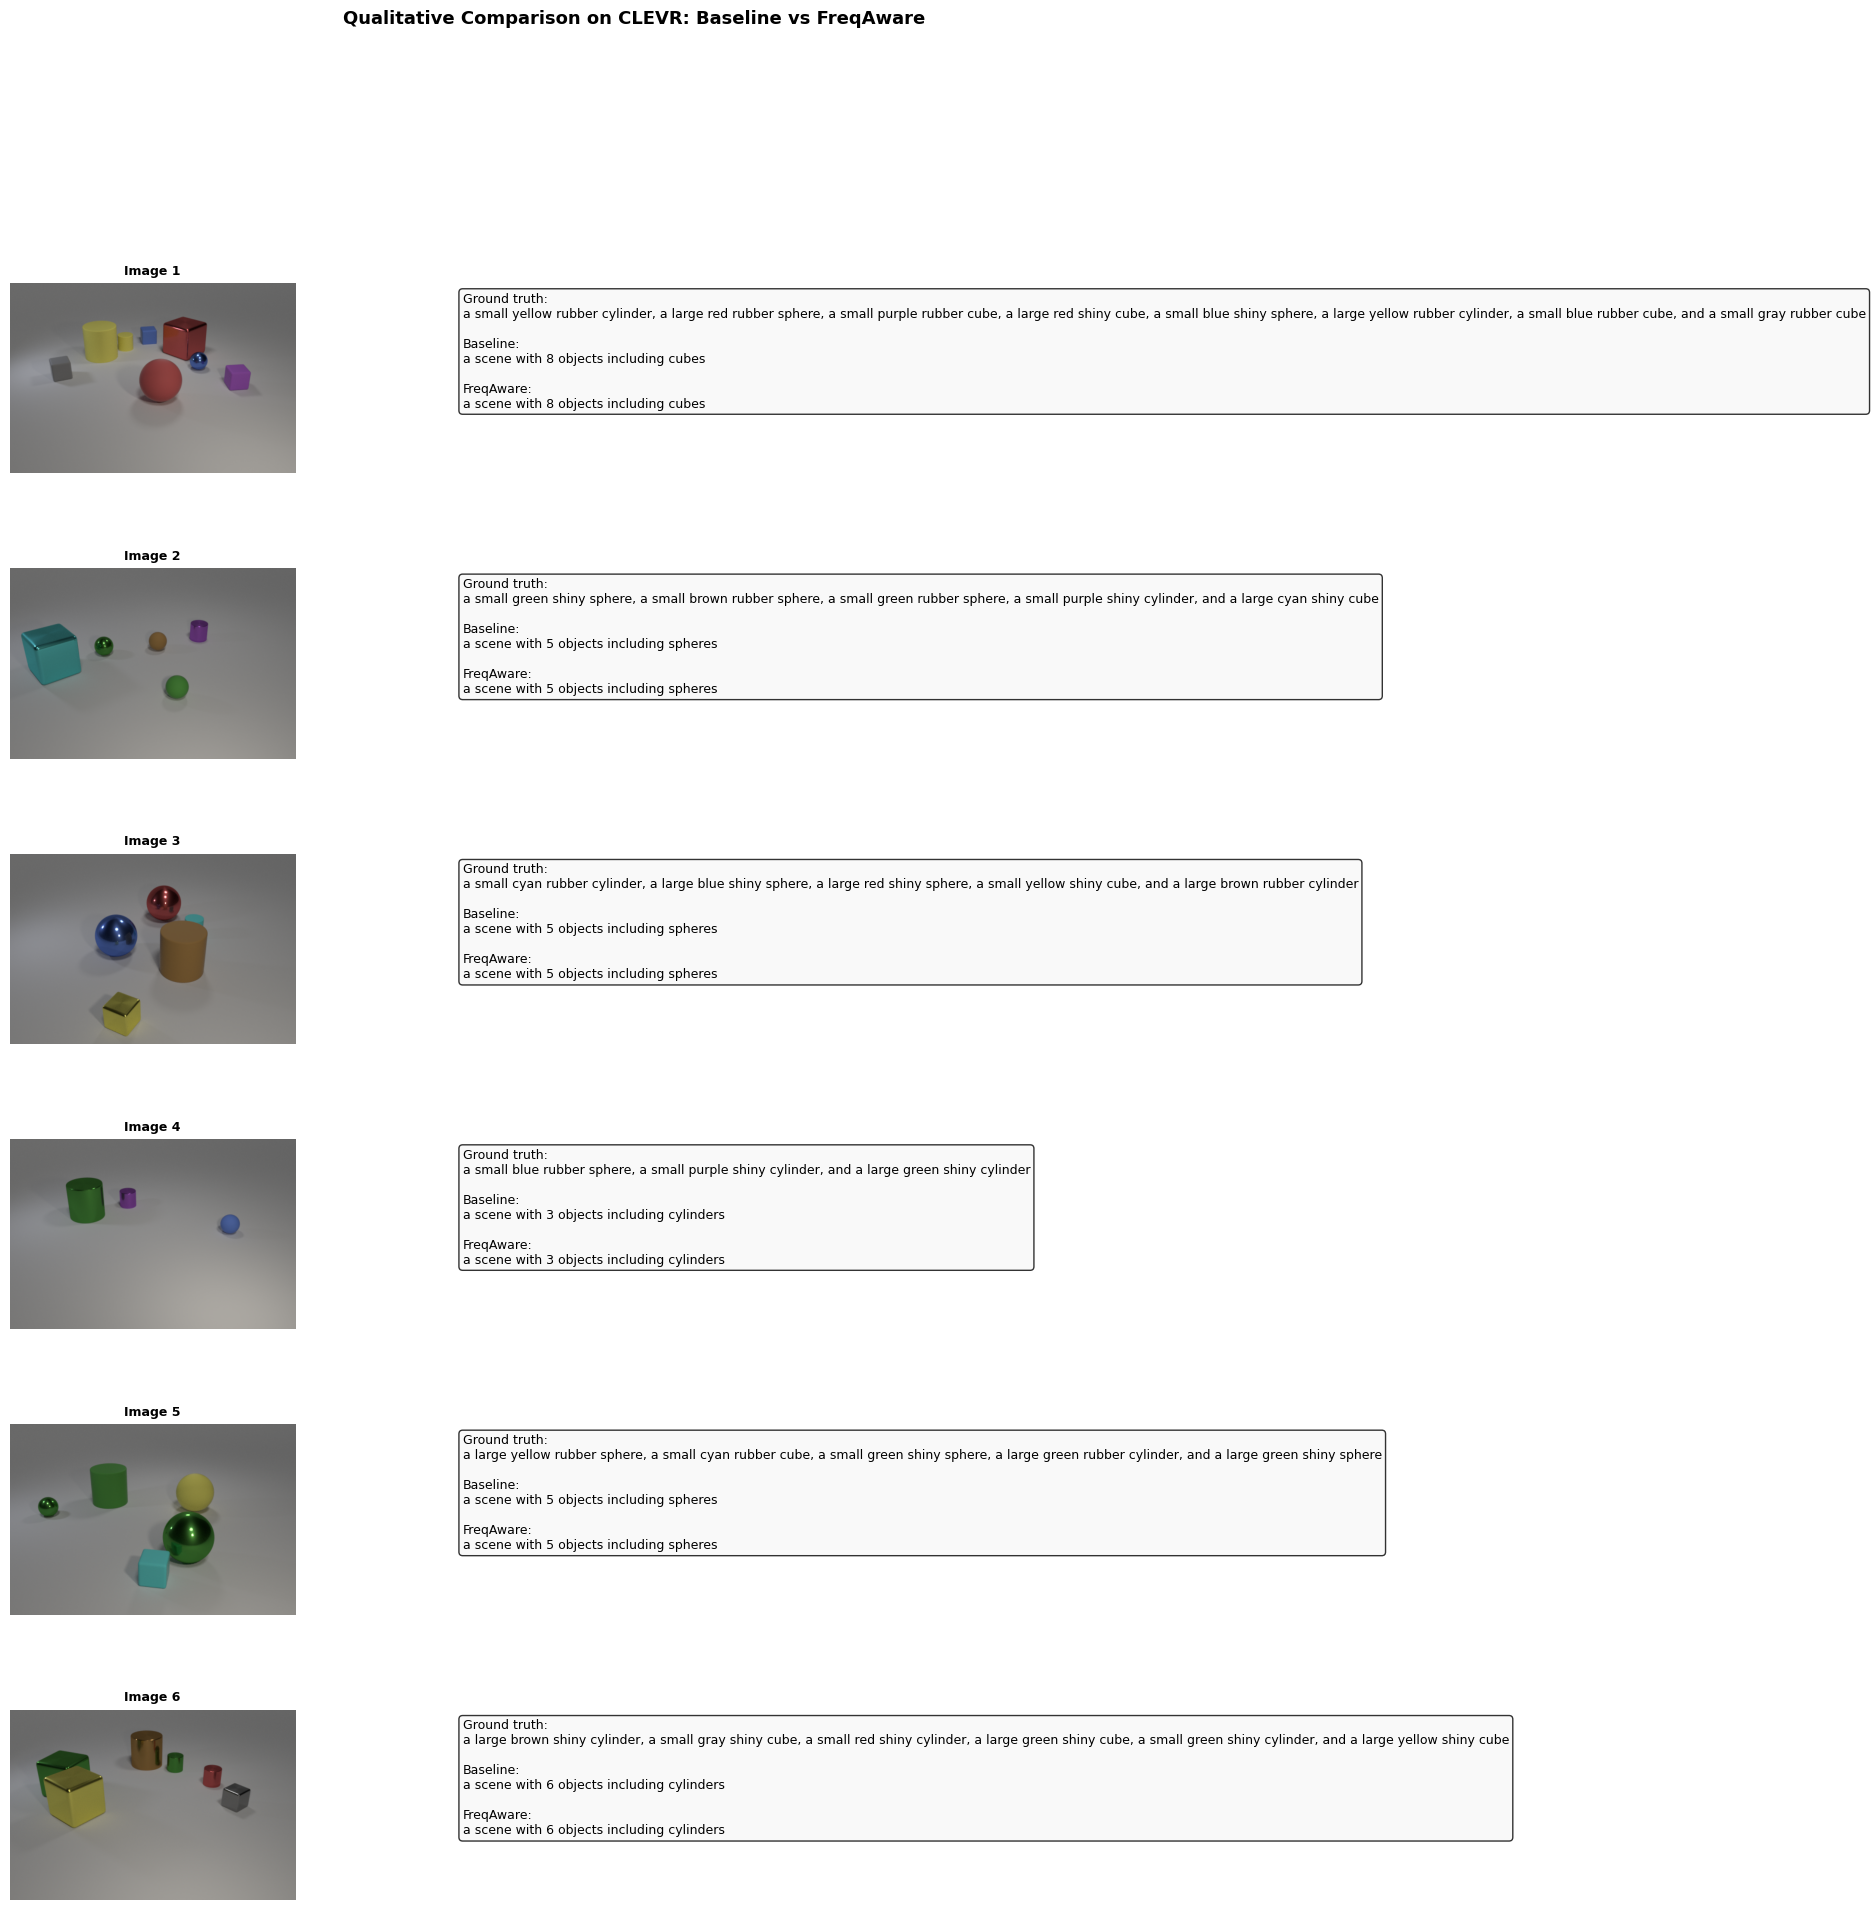

✅ Saved qualitative_clevr.png

✅ Cell 11 done.


In [20]:
# ============================================================
# CELL 11 — Visualization & Qualitative Analysis
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import random
import os
import json
from PIL import Image

# --------------------------------------------------------
# Plot BLEU comparison bar chart
# --------------------------------------------------------
def plot_bleu_comparison():
    labels      = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']
    base_scores = [b1, b2, b3, b4]
    freq_scores = [f1, f2, f3, f4]

    x     = range(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    bars1 = ax.bar([i - width/2 for i in x], base_scores,
                   width, label='Baseline',  color='steelblue', alpha=0.85)
    bars2 = ax.bar([i + width/2 for i in x], freq_scores,
                   width, label='FreqAware', color='tomato',    alpha=0.85)

    ax.set_xticks(list(x))
    ax.set_xticklabels(labels)
    ax.set_ylabel('BLEU Score')
    ax.set_ylim(0.90, 1.0)
    ax.set_title('BLEU Score Comparison on CLEVR: Baseline vs FreqAware')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'bleu_clevr.png'), dpi=120)
    plt.show()
    print("✅ Saved bleu_clevr.png")

# --------------------------------------------------------
# Plot cross-dataset comparison
# --------------------------------------------------------
def plot_cross_dataset():
    datasets  = ['Flickr8k', 'CLEVR']
    base_b4   = [0.217, b4]
    freq_b4   = [0.175, f4]

    x     = range(len(datasets))
    width = 0.35

    fig, ax = plt.subplots(figsize=(7, 5))
    bars1 = ax.bar([i - width/2 for i in x], base_b4,
                   width, label='Baseline',  color='steelblue', alpha=0.85)
    bars2 = ax.bar([i + width/2 for i in x], freq_b4,
                   width, label='FreqAware', color='tomato',    alpha=0.85)

    ax.set_xticks(list(x))
    ax.set_xticklabels(datasets, fontsize=12)
    ax.set_ylabel('BLEU-4')
    ax.set_title('BLEU-4 Comparison: Flickr8k vs CLEVR')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=9)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'cross_dataset_bleu4.png'), dpi=120)
    plt.show()
    print("✅ Saved cross_dataset_bleu4.png")

# --------------------------------------------------------
# Qualitative comparison
# --------------------------------------------------------
def show_qualitative(n_samples=6, seed=42):
    random.seed(seed)
    samples = random.sample(val_items, n_samples)

    fig = plt.figure(figsize=(18, n_samples * 3.5))
    gs  = gridspec.GridSpec(n_samples, 3, figure=fig,
                            wspace=0.3, hspace=0.5)

    for i, (img_name, data) in enumerate(samples):
        split    = data['split']
        img_path = os.path.join(IMAGES_DIR, split, img_name)
        img_pil  = Image.open(img_path).convert('RGB')
        img_t    = val_transform(img_pil)

        cap_base = ' '.join(generate_caption(baseline_model,  img_t))
        cap_freq = ' '.join(generate_caption(freqaware_model, img_t))
        gt       = data['captions'][0]

        ax_img = fig.add_subplot(gs[i, 0])
        ax_img.imshow(img_pil)
        ax_img.axis('off')
        ax_img.set_title(f'Image {i+1}', fontsize=9, fontweight='bold')

        ax_txt = fig.add_subplot(gs[i, 1:])
        ax_txt.axis('off')
        text = (f"Ground truth:\n{gt}\n\n"
                f"Baseline:\n{cap_base}\n\n"
                f"FreqAware:\n{cap_freq}")
        ax_txt.text(0, 0.95, text, transform=ax_txt.transAxes,
                    fontsize=9, verticalalignment='top',
                    bbox=dict(boxstyle='round',
                              facecolor='#f8f8f8', alpha=0.8))

    plt.suptitle('Qualitative Comparison on CLEVR: Baseline vs FreqAware',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.savefig(os.path.join(RESULTS_DIR, 'qualitative_clevr.png'),
                bbox_inches='tight', dpi=120)
    plt.show()
    print("✅ Saved qualitative_clevr.png")

# --------------------------------------------------------
# Run all
# --------------------------------------------------------
plot_bleu_comparison()
plot_cross_dataset()
show_qualitative(n_samples=6)

print("\n✅ Cell 11 done.")